Assignment 6: Applying AI-Based Style Transfer to an Image

Name: Ashif Hussain

Program: BCA (AI/ML), Alliance University


Date: 3 October 2026

In [17]:
# Step 1: Import libraries and check the GPU

# Import the main libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# Use GPU if it is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device in use:", device)

Device in use: cuda


Saving Mecca.webp to Mecca.webp


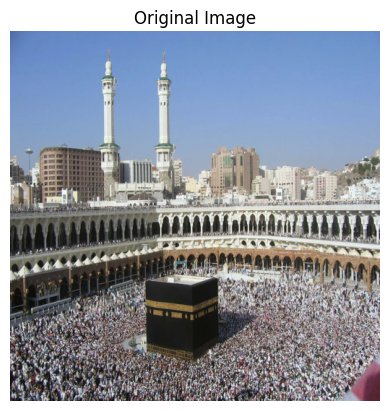

In [18]:
# Step 2: Upload and load the content image

from google.colab import files

# Upload a photo from your computer
uploaded = files.upload()

# Get the name of the uploaded file
file_name = list(uploaded.keys())[0]

# Open the image and convert it to RGB
content_img = Image.open(file_name).convert("RGB")

# Resize so both methods use the same size
content_img = content_img.resize((512, 512))

# Show the original image
plt.imshow(content_img)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [20]:
# Step 3: Download the CycleGAN code and install requirements

# Download the official CycleGAN repository
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git

# Move into the folder
%cd pytorch-CycleGAN-and-pix2pix

# Install the required packages
!pip install -q dominate visdom

print("CycleGAN code downloaded and requirements installed.")

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.24 MiB | 18.37 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.
/content/pytorch-CycleGAN-and-pix2pix/pytorch-CycleGAN-and-pix2pix/pytorch-CycleGAN-and-pix2pix
CycleGAN code downloaded and requirements installed.


In [21]:
# Step 4: Download the pretrained CycleGAN model (photo to Monet style)

# Download the pretrained weights using the script from the repository
!bash ./scripts/download_cyclegan_model.sh style_monet

print("Pretrained CycleGAN model downloaded.")

Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [style_monet]
for details.

--2026-10-03 17:16:53--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_monet.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.139.28
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’

./checkpoints/style 100%[===================>]  43.46M  11.6MB/s    in 3.9s    

2026-10-03 17:16:57 (11.0 MB/s) - ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’ saved [45575747/45575747]

Pretrain

In [22]:
# Step 5: Save the content image for CycleGAN

import os

# Make a folder for the input image
os.makedirs("input_images", exist_ok=True)

# Save the resized image as JPG inside that folder
content_img.save("input_images/mecca.jpg")

print("Image saved in the input_images folder.")

Image saved in the input_images folder.


In [23]:
# Step 6: Run the pretrained CycleGAN model on the image

# Test the model on the image saved in input_images
!python test.py --dataroot ./input_images --name style_monet_pretrained --model test --no_dropout --preprocess none --num_test 1 --results_dir ./results

print("CycleGAN output generated.")

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: ./input_images                	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256             

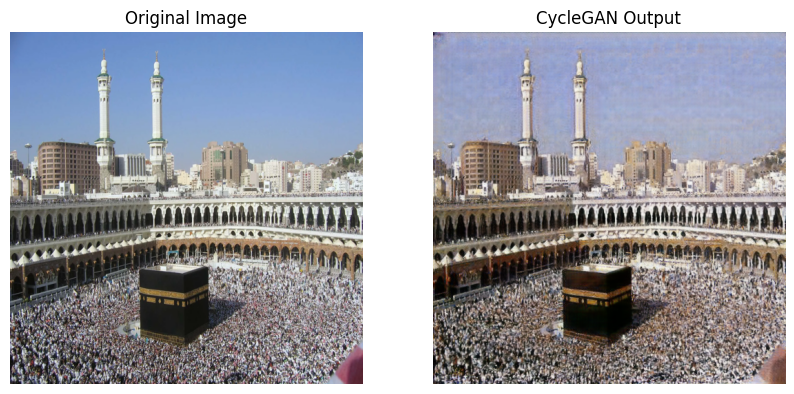

In [24]:
# Step 7: Load and show the CycleGAN output

# Path of the image generated by CycleGAN
cyclegan_path = "results/style_monet_pretrained/test_latest/images/mecca_fake.png"

# Open the output image and resize it to match the original
cyclegan_img = Image.open(cyclegan_path).convert("RGB")
cyclegan_img = cyclegan_img.resize((512, 512))

# Show the original and the CycleGAN output side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(content_img)
axes[0].set_title("Original Image")
axes[0].axis("off")
axes[1].imshow(cyclegan_img)
axes[1].set_title("CycleGAN Output")
axes[1].axis("off")
plt.show()

Saving vincent-van-gogh-the-starry-night.jpg to vincent-van-gogh-the-starry-night.jpg


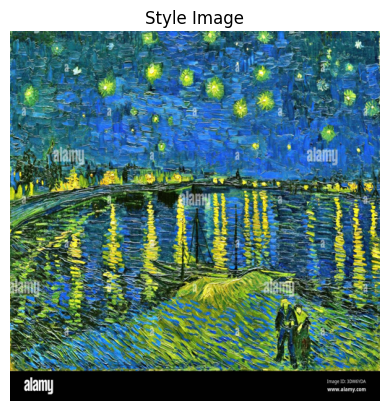

In [25]:
# Step 8: Upload and load the style image (a painting)

from google.colab import files

# Upload a painting from your computer
uploaded_style = files.upload()

# Get the name of the uploaded painting file
style_name = list(uploaded_style.keys())[0]

# Open the painting and convert it to RGB
style_img = Image.open(style_name).convert("RGB")

# Resize so it matches the content image
style_img = style_img.resize((512, 512))

# Show the style image
plt.imshow(style_img)
plt.title("Style Image")
plt.axis("off")
plt.show()


In [26]:
# Step 9: Prepare the images and load the VGG19 model

# Convert the images into tensors (numbers the model can read)
loader = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

content_tensor = loader(content_img).unsqueeze(0).to(device)
style_tensor = loader(style_img).unsqueeze(0).to(device)

# Load the pretrained VGG19 (feature part only) and freeze it
vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()
for param in vgg.parameters():
    param.requires_grad_(False)

# Mean and standard deviation that VGG19 expects
vgg_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
vgg_std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)

print("Images prepared and VGG19 model loaded.")
print("Content tensor shape:", content_tensor.shape)
print("Style tensor shape:", style_tensor.shape)

Images prepared and VGG19 model loaded.
Content tensor shape: torch.Size([1, 3, 512, 512])
Style tensor shape: torch.Size([1, 3, 512, 512])


In [27]:
# Step 10: Define feature extraction and the Gram matrix

# Make ReLU layers safe so saved features are not changed later
for layer in vgg:
    if isinstance(layer, nn.ReLU):
        layer.inplace = False

# VGG19 layers used for style and for content
style_layers = {0: "conv1_1", 5: "conv2_1", 10: "conv3_1", 19: "conv4_1", 28: "conv5_1"}
content_layers = {21: "conv4_2"}

def get_features(image):
    # Normalize the image the way VGG19 expects
    x = (image - vgg_mean) / vgg_std
    features = {}
    # Pass the image through each layer and save the chosen outputs
    for i, layer in enumerate(vgg):
        x = layer(x)
        if i in style_layers:
            features[style_layers[i]] = x
        if i in content_layers:
            features[content_layers[i]] = x
    return features

def gram_matrix(tensor):
    # Gram matrix captures the style (textures and colors) of a layer
    b, c, h, w = tensor.size()
    flat = tensor.view(c, h * w)
    return torch.mm(flat, flat.t()) / (c * h * w)

# Get the target features once (no training needed here)
with torch.no_grad():
    content_features = get_features(content_tensor)
    style_features = get_features(style_tensor)
    style_grams = {name: gram_matrix(style_features[name]) for name in style_layers.values()}

print("Feature extraction ready. Style layers:", len(style_grams))

Feature extraction ready. Style layers: 5


In [28]:
# Step 11: Run Neural Style Transfer

# Start from a copy of the content image and optimize its pixels
target = content_tensor.clone().requires_grad_(True)

# Weights: higher style weight gives a stronger painting look
content_weight = 1
style_weight = 1e6

# Per-layer style weights (earlier layers get more weight)
layer_weights = {"conv1_1": 1.0, "conv2_1": 0.8, "conv3_1": 0.5, "conv4_1": 0.3, "conv5_1": 0.1}

# LBFGS optimizer works well for style transfer
optimizer = optim.LBFGS([target])
num_steps = 300
run = [0]

def closure():
    # Keep pixel values in a valid range
    with torch.no_grad():
        target.clamp_(0, 1)
    optimizer.zero_grad()
    target_features = get_features(target)

    # Content loss: how different the content is from the original image
    content_loss = torch.mean((target_features["conv4_2"] - content_features["conv4_2"]) ** 2)

    # Style loss: how different the style is from the painting
    style_loss = 0
    for name in style_layers.values():
        target_gram = gram_matrix(target_features[name])
        layer_loss = torch.mean((target_gram - style_grams[name]) ** 2)
        style_loss += layer_weights[name] * layer_loss

    # Total loss combines both
    total_loss = content_weight * content_loss + style_weight * style_loss
    total_loss.backward()

    run[0] += 1
    if run[0] % 50 == 0:
        print(f"Iteration {run[0]} | Content loss: {content_loss.item():.4f} | Style loss: {style_loss.item():.6f}")
    return total_loss

# Keep running until we reach the number of steps
while run[0] <= num_steps:
    optimizer.step(closure)

# Final clamp to keep pixels valid
with torch.no_grad():
    target.clamp_(0, 1)

print("Neural Style Transfer completed.")

Iteration 50 | Content loss: 90.2046 | Style loss: 0.000166
Iteration 100 | Content loss: 73.2060 | Style loss: 0.000065
Iteration 150 | Content loss: 63.4926 | Style loss: 0.000044
Iteration 200 | Content loss: 58.1084 | Style loss: 0.000035
Iteration 250 | Content loss: 54.9584 | Style loss: 0.000028
Iteration 300 | Content loss: 52.4700 | Style loss: 0.000023
Neural Style Transfer completed.


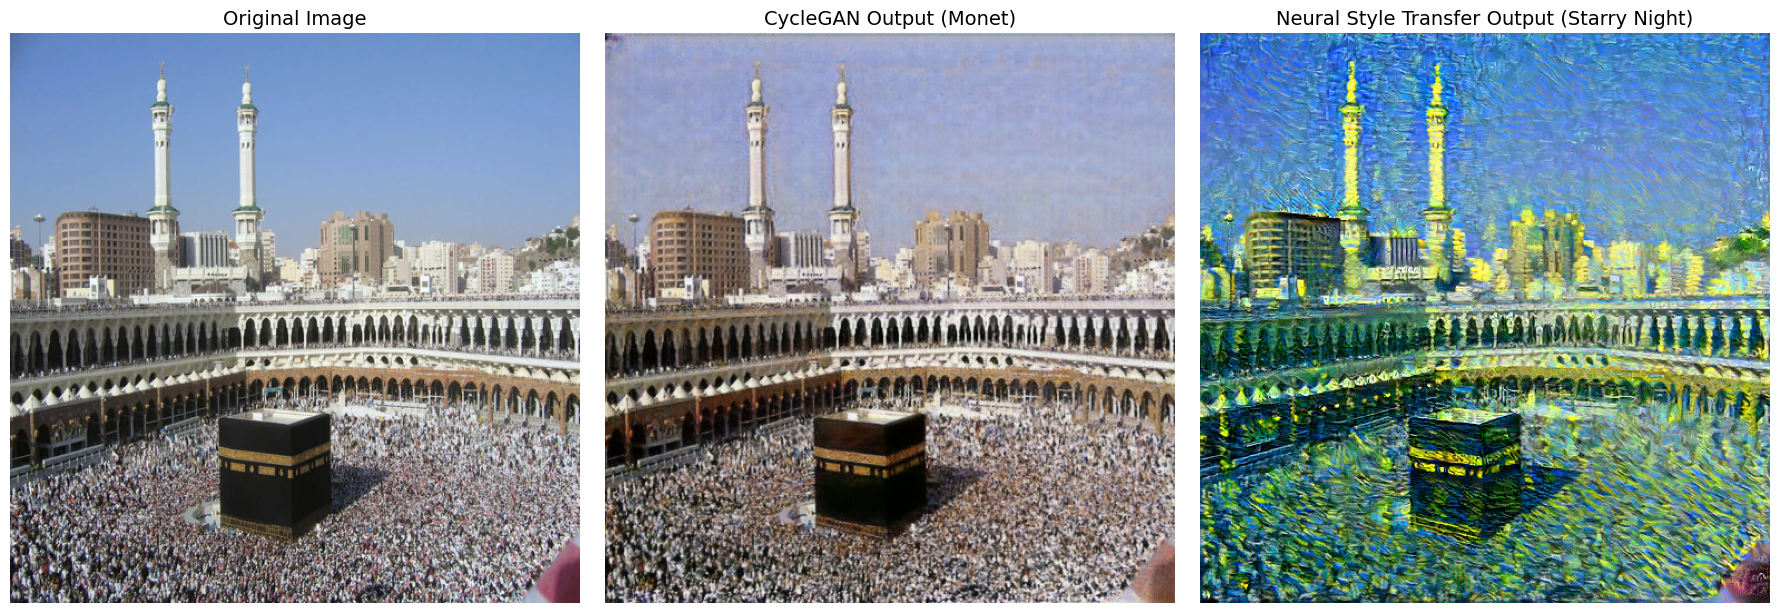

Comparison image saved as comparison.png


In [29]:
# Step 12: Show the final comparison of all three images

# Convert the NST tensor back into an image
nst_img = target.detach().cpu().squeeze(0).permute(1, 2, 0).numpy()

# Show the three images side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(content_img)
axes[0].set_title("Original Image", fontsize=14)
axes[0].axis("off")

axes[1].imshow(cyclegan_img)
axes[1].set_title("CycleGAN Output (Monet)", fontsize=14)
axes[1].axis("off")

axes[2].imshow(nst_img)
axes[2].set_title("Neural Style Transfer Output (Starry Night)", fontsize=14)
axes[2].axis("off")

plt.tight_layout()

# Save the comparison picture for the submission document
plt.savefig("/content/comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("Comparison image saved as comparison.png")

In [30]:
# Step 15: Download the comparison image to your computer

from google.colab import files

# Download the saved comparison picture
files.download("/content/comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Comparison:

CycleGAN preserved the original content better. The mosque, buildings and crowd stayed clear and in the same place, and only the colors changed slightly to look like a Monet painting. This is because of cycle consistency: the painted image should be convertible back into the original photo, so the structure of the photo is kept.

Neural Style Transfer produced the stronger style transformation. The brushstrokes and the blue and yellow colors of Starry Night are clearly visible, but some small details of the buildings became less clear. In short, CycleGAN gives a soft and safe change, while Neural Style Transfer gives a bold, painting-like change.
